# Cutouts and Capacity Factors (2016-2025)

This notebook creates ERA5 cutouts (.nc) for 2016-2025 and computes wind/solar capacity factors using the same workflow as `config.py` and `case_analysis.ipynb`.

Important:
- Set `GENERATE_CUTOUTS = True` only when you want to create missing .nc files.
- Keep it `False` for analysis-only runs.

In [1]:
import importlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import config
config = importlib.reload(config)

# -------- User parameters --------
CASE_FOLDER = "input_punta_arenas"
CASE_NAME = "magallanes"
YEARS = list(range(2016, 2026))

# Turn on only when you need to create/update .nc files
GENERATE_CUTOUTS = True
OVERWRITE_EXISTING_CUTOUTS = False

# VRE method and technology assumptions (same family as case_analysis.ipynb)
VRE_METHOD = "atlite_technology"
WIND_TURBINE = "Vestas_V112_3MW"
SOLAR_PANEL = "CSi"
SOLAR_ORIENTATION = "latitude_optimal"

# Preferred target grid for new consistent cutouts
DX = 0.25
DY = 0.25

# Grid locking mode:
# - "fixed_bounds": fixed geographic box (used here for full Magallanes)
# - "match_existing_year": force all years to match one existing cutout
# - "use_nodes_bounds": use nodes +/-1 deg with DX,DY above
GRID_LOCK_MODE = "fixed_bounds"
FIXED_BOUNDS = (-76.0, -66.0, -56.0, -50.0)  # Full Magallanes
REFERENCE_YEAR_FOR_GRID = 2019

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"Case: {CASE_NAME}")
print(f"Years: {YEARS[0]}-{YEARS[-1]}")
print(f"Generate cutouts: {GENERATE_CUTOUTS}")
print(f"Overwrite existing cutouts: {OVERWRITE_EXISTING_CUTOUTS}")
print(f"Grid lock mode: {GRID_LOCK_MODE}")

Case: magallanes
Years: 2016-2025
Generate cutouts: True
Overwrite existing cutouts: False
Grid lock mode: fixed_bounds


In [2]:
import numpy as np
import xarray as xr

paths = config.get_case_paths(CASE_FOLDER)
nodes_df = config.load_nodes_from_csv(paths["csv_nodes"])
if nodes_df is None or nodes_df.empty:
    raise ValueError("Nodes CSV is empty or missing.")

if not {"lat", "lon"}.issubset(nodes_df.columns):
    raise ValueError("Nodes CSV must include lat and lon columns.")

valid_coords = nodes_df[["lat", "lon"]].dropna()
if valid_coords.empty:
    raise ValueError("No valid lat/lon coordinates found in nodes CSV.")

padding_deg = 1.0
lon_min = float(valid_coords["lon"].min()) - padding_deg
lon_max = float(valid_coords["lon"].max()) + padding_deg
lat_min = float(valid_coords["lat"].min()) - padding_deg
lat_max = float(valid_coords["lat"].max()) + padding_deg
derived_bounds = (lon_min, lon_max, lat_min, lat_max)

# Resolve canonical grid once, then reuse for all years.
if GRID_LOCK_MODE == "fixed_bounds":
    lock_bounds = tuple(float(v) for v in FIXED_BOUNDS)
    lock_dx = float(DX)
    lock_dy = float(DY)
elif GRID_LOCK_MODE == "match_existing_year":
    ref_path = DATA_DIR / f"{CASE_NAME}_{REFERENCE_YEAR_FOR_GRID}.nc"
    if not ref_path.exists():
        raise FileNotFoundError(
            f"Reference cutout not found for grid lock mode: {ref_path}"
        )
    with xr.open_dataset(ref_path) as ds_ref:
        x_vals = np.array(ds_ref["x"].values)
        y_vals = np.array(ds_ref["y"].values)
        lon_min_lock = float(np.min(x_vals))
        lon_max_lock = float(np.max(x_vals))
        lat_min_lock = float(np.min(y_vals))
        lat_max_lock = float(np.max(y_vals))
        dx_lock = float(np.median(np.diff(np.sort(np.unique(x_vals)))))
        dy_lock = float(np.median(np.diff(np.sort(np.unique(y_vals)))))

    lock_bounds = (lon_min_lock, lon_max_lock, lat_min_lock, lat_max_lock)
    lock_dx = dx_lock
    lock_dy = dy_lock
else:
    lock_bounds = derived_bounds
    lock_dx = float(DX)
    lock_dy = float(DY)

print("Nodes used for VRE profiles:")
display(nodes_df[["zone", "lat", "lon"]])

print("\nDerived bounds from nodes (+/-1 deg):")
print(f"lon_min={lon_min:.4f}, lon_max={lon_max:.4f}, lat_min={lat_min:.4f}, lat_max={lat_max:.4f}")

print("\nCanonical grid to use for all generated years:")
print(f"bounds={lock_bounds}")
print(f"dx={lock_dx}, dy={lock_dy}")

Nodes used for VRE profiles:


,zone,lat,lon
0,punta_arenas_1,-53.16,-70.93
1,punta_arenas_2,-53.16,-70.89



Derived bounds from nodes (+/-1 deg):
lon_min=-71.9300, lon_max=-69.8900, lat_min=-54.1600, lat_max=-52.1600

Canonical grid to use for all generated years:
bounds=(-76.0, -66.0, -56.0, -50.0)
dx=0.25, dy=0.25


In [3]:

# ── Connectivity & credentials diagnostic ─────────────────────────────────────
import subprocess, socket, urllib.request, json, os, time

print("=" * 60)
print("1. DNS resolution — cds.climate.copernicus.eu")
try:
    ip = socket.gethostbyname("cds.climate.copernicus.eu")
    print(f"   OK  → {ip}")
except Exception as e:
    print(f"   FAIL → {e}")

print()
print("2. HTTP GET — CDS API root (5 s timeout)")
try:
    t0 = time.time()
    with urllib.request.urlopen("https://cds.climate.copernicus.eu/api", timeout=5) as r:
        print(f"   OK  → HTTP {r.status}  ({time.time()-t0:.1f}s)")
except Exception as e:
    print(f"   FAIL → {e}")

print()
print("3. CDS API credentials (~/.cdsapirc)")
cdsapirc = os.path.expanduser("~/.cdsapirc")
if os.path.exists(cdsapirc):
    with open(cdsapirc) as f:
        lines = f.read().splitlines()
    for line in lines:
        if line.startswith("key"):
            # mask key value, show only first 6 chars
            parts = line.split(":", 1)
            val = parts[1].strip() if len(parts) > 1 else ""
            masked = val[:6] + "****" if len(val) > 6 else "****"
            print(f"   key: {masked}")
        else:
            print(f"   {line}")
else:
    print("   MISSING — create ~/.cdsapirc with url and key")

print()
print("4. Quick cdsapi ping (actual API call, 10 s timeout)")
try:
    import cdsapi
    c = cdsapi.Client(quiet=True, wait_until_complete=False, retry_max=1)
    print("   Client created OK")
except Exception as e:
    print(f"   FAIL → {e}")

print("=" * 60)


1. DNS resolution — cds.climate.copernicus.eu
   OK  → 136.156.139.54

2. HTTP GET — CDS API root (5 s timeout)
   OK  → HTTP 202  (1.0s)

3. CDS API credentials (~/.cdsapirc)
   url: https://cds.climate.copernicus.eu/api
   key: a730a8****

4. Quick cdsapi ping (actual API call, 10 s timeout)
   Client created OK


In [4]:
# Validation of generated cutouts (existence, size, readability, metadata)
import xarray as xr

years_check = [2016, 2017, 2018, 2019]
rows = []

for y in years_check:
    p = DATA_DIR / f"{CASE_NAME}_{y}.nc"
    rec = {
        "year": y,
        "exists": p.exists(),
        "size_MB": None,
        "open_ok": False,
        "time_len": None,
        "x_len": None,
        "y_len": None,
        "time_start": None,
        "time_end": None,
        "n_data_vars": None,
    }

    if p.exists():
        rec["size_MB"] = p.stat().st_size / (1024**2)
        try:
            with xr.open_dataset(p) as ds:
                rec["open_ok"] = True
                rec["time_len"] = int(ds.sizes.get("time", 0))
                rec["x_len"] = int(ds.sizes.get("x", 0))
                rec["y_len"] = int(ds.sizes.get("y", 0))
                rec["n_data_vars"] = int(len(ds.data_vars))
                if "time" in ds.coords and ds.sizes.get("time", 0) > 0:
                    rec["time_start"] = str(ds["time"].values[0])
                    rec["time_end"] = str(ds["time"].values[-1])
        except Exception as e:
            rec["open_ok"] = False
            rec["time_start"] = f"ERROR: {e}"

    rows.append(rec)

check_df = pd.DataFrame(rows)

print("Cutout validation (2016-2019):")
display(check_df)

ok_files = check_df[(check_df["exists"]) & (check_df["open_ok"])].copy()
if not ok_files.empty:
    min_mb = ok_files["size_MB"].min()
    max_mb = ok_files["size_MB"].max()
    ratio = (max_mb / min_mb) if min_mb and min_mb > 0 else None
    print(f"Size range among valid files: {min_mb:.2f} MB to {max_mb:.2f} MB")
    if ratio is not None:
        print(f"Max/min size ratio: {ratio:.3f}")

    same_grid = ok_files[["x_len", "y_len"]].nunique().max() == 1
    print(f"Same spatial grid across valid files: {same_grid}")

    same_time_len = ok_files["time_len"].nunique() == 1
    print(f"Same number of timesteps across valid files: {same_time_len}")
else:
    print("No valid files found to compare.")

Cutout validation (2016-2019):


,year,exists,size_MB,open_ok,time_len,x_len,y_len,time_start,time_end,n_data_vars
0,2016,True,313.890235,True,8784,41,25,2016-01-01T00:00:00.000000000,2016-12-31T23:00:00.000000000,15
1,2017,True,313.225304,True,8760,41,25,2017-01-01T00:00:00.000000000,2017-12-31T23:00:00.000000000,15
2,2018,True,313.418809,True,8760,41,25,2018-01-01T00:00:00.000000000,2018-12-31T23:00:00.000000000,15
3,2019,True,313.209021,True,8760,41,25,2019-01-01T00:00:00.000000000,2019-12-31T23:00:00.000000000,15


Size range among valid files: 313.21 MB to 313.89 MB
Max/min size ratio: 1.002
Same spatial grid across valid files: True
Same number of timesteps across valid files: False


In [5]:
# Compare spatial extent/resolution across cutouts
import numpy as np

extent_rows = []
for y in YEARS:
    p = DATA_DIR / f"{CASE_NAME}_{y}.nc"
    if not p.exists():
        continue

    with xr.open_dataset(p) as ds:
        x_vals = np.array(ds["x"].values)
        y_vals = np.array(ds["y"].values)
        extent_rows.append({
            "year": y,
            "x_min": float(np.min(x_vals)),
            "x_max": float(np.max(x_vals)),
            "y_min": float(np.min(y_vals)),
            "y_max": float(np.max(y_vals)),
            "dx_inferred": float(np.median(np.diff(np.sort(np.unique(x_vals))))) if len(np.unique(x_vals)) > 1 else np.nan,
            "dy_inferred": float(np.median(np.diff(np.sort(np.unique(y_vals))))) if len(np.unique(y_vals)) > 1 else np.nan,
            "x_len": int(len(np.unique(x_vals))),
            "y_len": int(len(np.unique(y_vals))),
        })

extent_df = pd.DataFrame(extent_rows)
print("Spatial extent/resolution by year:")

if extent_df.empty:
    print("No cutout files found yet. Run the generation cell first or set GENERATE_CUTOUTS = True.")
else:
    extent_df = extent_df.sort_values("year")
    display(extent_df)

    reference = extent_df.iloc[0]
    same_extent = (
        (extent_df["x_min"] == reference["x_min"]).all()
        and (extent_df["x_max"] == reference["x_max"]).all()
        and (extent_df["y_min"] == reference["y_min"]).all()
        and (extent_df["y_max"] == reference["y_max"]).all()
    )
    same_resolution = (
        np.isclose(extent_df["dx_inferred"], reference["dx_inferred"]).all()
        and np.isclose(extent_df["dy_inferred"], reference["dy_inferred"]).all()
    )
    print(f"All years have same extent: {same_extent}")
    print(f"All years have same resolution: {same_resolution}")

Spatial extent/resolution by year:


,year,x_min,x_max,y_min,y_max,dx_inferred,dy_inferred,x_len,y_len
0,2016,-76.0,-66.0,-56.0,-50.0,0.25,0.25,41,25
1,2017,-76.0,-66.0,-56.0,-50.0,0.25,0.25,41,25
2,2018,-76.0,-66.0,-56.0,-50.0,0.25,0.25,41,25
3,2019,-76.0,-66.0,-56.0,-50.0,0.25,0.25,41,25
4,2020,-76.0,-66.0,-56.0,-50.0,0.25,0.25,41,25
5,2021,-76.0,-66.0,-56.0,-50.0,0.25,0.25,41,25
6,2022,-76.0,-66.0,-56.0,-50.0,0.25,0.25,41,25


All years have same extent: True
All years have same resolution: True


In [6]:
existing = []
created = []
missing = []

for year in YEARS:
    cutout_file = DATA_DIR / f"{CASE_NAME}_{year}.nc"
    exists_before = cutout_file.exists()

    if GENERATE_CUTOUTS:
        force_prepare = OVERWRITE_EXISTING_CUTOUTS or (not exists_before)
        _ = config.get_case_cutout(
            year=year,
            force_prepare=force_prepare,
            base_dir="data",
            case_name=CASE_NAME,
            bounds=lock_bounds,
            nodes_df=nodes_df,
            dx=lock_dx,
            dy=lock_dy,
        )

    if cutout_file.exists():
        if exists_before:
            existing.append(year)
        else:
            created.append(year)
    else:
        missing.append(year)

print(f"Existing cutouts: {existing}")
print(f"Created now: {created}")
print(f"Missing cutouts: {missing}")

if missing and not GENERATE_CUTOUTS:
    print("\nSome cutouts are missing. Set GENERATE_CUTOUTS = True and run this cell once.")

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning: Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.
  warn(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning: Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.
  warn(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning: Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.
  warn(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning: Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.
  warn(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning: Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.
  w

fcbadafb6ca396fe92022237ef95ad5f.grib:   0%|          | 0.00/18.0M [00:00<?, ?B/s]

3c271518e7090166f4e7b5df0f3d4df6.grib:   0%|          | 0.00/72.1M [00:00<?, ?B/s]

32825028f9bb8d386a15b27e1b3219ff.grib:   0%|          | 0.00/3.11k [00:00<?, ?B/s]

738146d32635f0dae2824cacadce9cf2.grib:   0%|          | 0.00/98.7M [00:00<?, ?B/s]

...

c0496c29a5114446657e2be991a0c9ee.grib:   0%|          | 0.00/18.0M [00:00<?, ?B/s]

8b8fdc550d92549edfcb548613148b1e.grib:   0%|          | 0.00/3.11k [00:00<?, ?B/s]

5fa0f62a1d2606cc84669f5664bca2d1.grib:   0%|          | 0.00/72.1M [00:00<?, ?B/s]

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\data.py:250: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = cutout.data.merge(ds[missing_vars.values]).assign_attrs(**attrs)
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\data.py:250: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set c

Existing cutouts: [2016, 2017, 2018, 2019, 2020, 2021, 2022]
Created now: [2023, 2024, 2025]
Missing cutouts: []


In [7]:
summary_rows = []
zone_rows = []

for year in YEARS:
    cutout_file = DATA_DIR / f"{CASE_NAME}_{year}.nc"
    if not cutout_file.exists():
        continue

    cutout = config.get_case_cutout(
        year=year,
        force_prepare=False,
        base_dir="data",
        case_name=CASE_NAME,
        bounds=lock_bounds,
        nodes_df=nodes_df,
        dx=lock_dx,
        dy=lock_dy,
    )

    wind_cf, solar_cf = config.get_vre_profiles_from_cutout(
        cutout=cutout,
        nodes_df=nodes_df,
        method=VRE_METHOD,
        wind_turbine=WIND_TURBINE,
        solar_panel=SOLAR_PANEL,
        solar_orientation=SOLAR_ORIENTATION,
    )

    summary_rows.append({
        "year": year,
        "hours": len(wind_cf),
        "wind_cf_mean_system": float(wind_cf.mean().mean()),
        "solar_cf_mean_system": float(solar_cf.mean().mean()),
    })

    for zone in wind_cf.columns:
        zone_rows.append({
            "year": year,
            "zone": zone,
            "wind_cf_mean": float(wind_cf[zone].mean()),
            "solar_cf_mean": float(solar_cf[zone].mean()),
        })

summary_df = pd.DataFrame(summary_rows).sort_values("year").reset_index(drop=True)
zone_df = pd.DataFrame(zone_rows).sort_values(["year", "zone"]).reset_index(drop=True)

if summary_df.empty:
    raise RuntimeError("No cutouts available to compute capacity factors.")

summary_csv = DATA_DIR / f"{CASE_NAME}_cf_summary_2016_2025.csv"
zone_csv = DATA_DIR / f"{CASE_NAME}_cf_by_zone_2016_2025.csv"
summary_df.to_csv(summary_csv, index=False)
zone_df.to_csv(zone_csv, index=False)

print(f"Saved: {summary_csv}")
print(f"Saved: {zone_csv}")
display(summary_df)
display(zone_df.head(20))

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning: Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.
  warn(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\convert.py:739: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\convert.py:929: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\convert.py:739: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.con

Saved: data\magallanes_cf_summary_2016_2025.csv
Saved: data\magallanes_cf_by_zone_2016_2025.csv


,year,hours,wind_cf_mean_system,solar_cf_mean_system
0,2016,8784,0.500020,0.131517
1,2017,8760,0.538505,0.128706
2,2018,8760,0.532833,0.131217
3,2019,8760,0.541609,0.129814
4,2020,8784,0.519461,0.122802
5,2021,8760,0.563112,0.128109
6,2022,8760,0.559219,0.132089
7,2023,8760,0.581050,0.135334
8,2024,8784,0.534392,0.125450
9,2025,8760,0.540015,0.131405


,year,zone,wind_cf_mean,solar_cf_mean
0,2016,punta_arenas_1,0.500020,0.131517
1,2016,punta_arenas_2,0.500020,0.131517
2,2017,punta_arenas_1,0.538505,0.128706
3,2017,punta_arenas_2,0.538505,0.128706
4,2018,punta_arenas_1,0.532833,0.131217
5,2018,punta_arenas_2,0.532833,0.131217
6,2019,punta_arenas_1,0.541609,0.129814
7,2019,punta_arenas_2,0.541609,0.129814
8,2020,punta_arenas_1,0.519461,0.122802
9,2020,punta_arenas_2,0.519461,0.122802


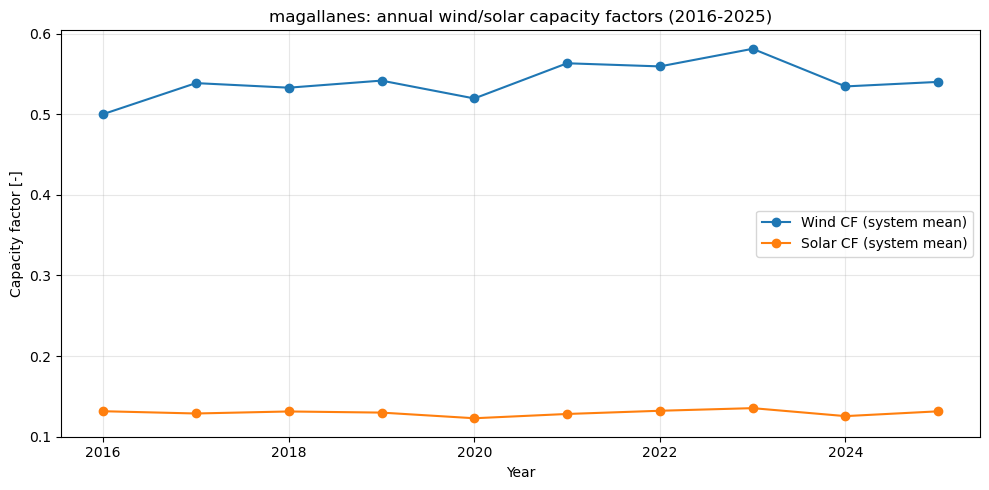

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(summary_df["year"], summary_df["wind_cf_mean_system"], marker="o", label="Wind CF (system mean)")
plt.plot(summary_df["year"], summary_df["solar_cf_mean_system"], marker="o", label="Solar CF (system mean)")
plt.title(f"{CASE_NAME}: annual wind/solar capacity factors (2016-2025)")
plt.xlabel("Year")
plt.ylabel("Capacity factor [-]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()